# **Homework 1**
## Task 1

Assuming that the data points are i.i.d
$$\text{MLE} = \prod_{i=1}^{n} P(x_i | \theta)$$

The goal is to maximize MLE:

$$\hat{\theta}_{MLE} = \underset{\theta}{\operatorname{argmax}} \prod_{i=1}^{n} P(x_i | \theta)$$

This is equivalent to taking to log of the MLE

$$\hat{\theta}_{MLE} = \underset{\theta}{\operatorname{argmax}} \text{log}( \prod_{i=1}^{n} P(x_i | \theta))$$

$$\hat{\theta}_{MLE} = \underset{\theta}{\operatorname{argmax}}  \sum_{i=1}^{n} \text{log}(P(x_i | \theta))$$

Here, we can transition from a maximization problem to a minimization problem, by taking the minimum of the negation.

$$\hat{\theta}_{MLE} = \underset{\theta}{\operatorname{argmin}} \text{Loss}(\theta)$$

where

$$\text{Loss}(\theta) = -\sum_{i=1}^{n} \text{log}(P(x_i | \theta))$$


Going back to logistic regression, it's classifier is defined as the sigmoid function:

$$P(y_i = 1 | x_i; \theta) = h_\theta(x_i) = \frac{1}{1 + e^{-\theta^T x_i}}$$

$$P(y_i = 0 | x_i; \theta) = 1 - h_\theta(x_i)$$

We can combine these assuming a Bernoulli distribution:

$$P(y_i | x_i; \theta) = [h_\theta(x_i)]^{y_i} \cdot [1 - h_\theta(x_i)]^{(1 - y_i)}$$

$$\text{Loss}(\theta) = -\sum_{i=1}^{n} \log \left( [h_\theta(x_i)]^{y_i} \cdot [1 - h_\theta(x_i)]^{(1 - y_i)} \right)$$

$$\text{Loss}(\theta) = -\sum_{i=1}^{n} \left[ y_i \log(h_\theta(x_i)) + (1 - y_i) \log(1 - h_\theta(x_i)) \right]$$

This is the binary cross entropy that we end up with.

We can continue to simplify this function using the properties of the sigmoid to make computation more efficent.

Let $\ell_i$ be what's inside the summation.

$$\ell_i = y_i \log \left( \frac{1}{1 + e^{-\mathbf{w}^T \mathbf{x}_i}} \right) + (1 - y_i) \log \left( 1 - \frac{1}{1 + e^{-\mathbf{w}^T \mathbf{x}_i}} \right)$$

$$\ell_i = y_i \log \left(\frac{\left( \frac{1}{1 + e^{-\mathbf{w}^T \mathbf{x}_i}} \right)}{\left( 1 - \frac{1}{1 + e^{-\mathbf{w}^T \mathbf{x}_i}} \right)}\right) + \log \left( 1 - \frac{1}{1 + e^{-\mathbf{w}^T \mathbf{x}_i}} \right)$$

$$\ell_i = y_i \log \left(\frac{\left( \frac{1}{1 + e^{-\mathbf{w}^T \mathbf{x}_i}} \right)}{\left( \frac{e^{-\mathbf{w}^T \mathbf{x}_i}}{1 + e^{-\mathbf{w}^T \mathbf{x}_i}} \right)}\right) + \log \left( 1 - \frac{1}{1 + e^{-\mathbf{w}^T \mathbf{x}_i}} \right)$$

$$\ell_i = y_i \log \left(e^{\mathbf{w}^T \mathbf{x}_i}\right) + \log \left( 1 - \frac{1}{1 + e^{-\mathbf{w}^T \mathbf{x}_i}} \right)$$

$$\ell_i = y_i \log \mathbf{w}^T \mathbf{x}_i+ \log \left( 1 - \frac{1}{1 + e^{-\mathbf{w}^T \mathbf{x}_i}} \right)$$

$$\ell_i = y_i \log \mathbf{w}^T \mathbf{x}_i+ \log \left( 1 - \frac{1}{1 + e^{-\mathbf{w}^T \mathbf{x}_i}} \right)$$


# MAP

The MAP technique differs from vanilla logistic regression by changing from the frequentist approach to the bayesian approach. The MLE approach assumes that the weights are static and not changing. The MAP approach has variable weights, changing with new information.

The updated objective (log) function is:

$$\theta_{MAP} = \arg \max_{\theta} \left[ \sum_{i=1}^{n} \log P(y_i | x_i, \theta) + \log P(\theta) \right]$$

From a machine learning perspective, the extra log term that was added can be thought of as the penalty term, penalizing complexity of the weights. This way, MAP has a way to regularize that MLE does not have the ability to.

[
https://www.geeksforgeeks.org/machine-learning/maximum-a-posteriori-map-estimation/](https://)

# Machine Learning Problem

The machine learning problem that I've decided to solve is:

"Predict the probability that the Arabica Futures market will enter a 'Bullish' regime over the next $t$ days, based on cumulative agro-climatic stress factors observed over the preceding $w$ days"

Logistic Regression is the best model for this problem because you are trying to get a probability based off the data, and logistic regression is the perfect model for this task. The reason that probability is preferred for this problem is because traders use these models to gauge what action they should take with a stock. A proabability is useful in many finance based models such as the Kelly Criterion. In addition, the simplicity that comes with logistic regression allows for coefficents of the weights to explain natural phenomenon.

## Compare with SVM

Some strengths of the SVM compared to Logistic Regression is the ability to regularize outliers within the data. Logistic regression tries to fit every point.

However, the SVM is not able to directly output probabilities, other algorithms must be used to transform the output. Thus, extra complexity is added to the problem.

## Variables

Target Variable ($Y$): Binary Classification.

$Y = 1$ (Bullish/Shortfall): If the 30-day forward rolling mean of price is $> 5\%$ higher than the current price.

$Y = 0$ (Bearish/Surplus): Otherwise.

Input Features ($X$): A flattened vector of aggregated weather anomalies (e.g., "National Rainfall Deficit Index", "Cumulative Degree Days").

The **assumption** that the variables are i.i.d is not true in this time series data. To fix this, during SGD, the variables should be sequentially looked at instead of randomly sampled, that way the model training resembles online learning that would occur normally.


# Dataset

https://www.kaggle.com/datasets/escstockholm/coffee-data-set

This dataset is an aggregation of coffee environmental data from 2000 to 2025.

/tmp/ipython-input-1876242461.py:8: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/myDrive/coffee_data.csv')


Variance Inflation Factor
                  Feature       VIF
1                Avg_Temp  3.642930
2        Precipitation_mm  1.538567
3                Humidity  4.108484
4         Solar_Radiation  1.465352
5              brl_return  1.467195
6              cny_return  1.019774
7              mxn_return  1.472834
8   Precipitation_mm_lag7  1.538071
9           Avg_Temp_lag7  3.578260
10          Humidity_lag7  3.491059
11           Rain_30d_Avg  2.525699


<Figure size 1400x1200 with 0 Axes>

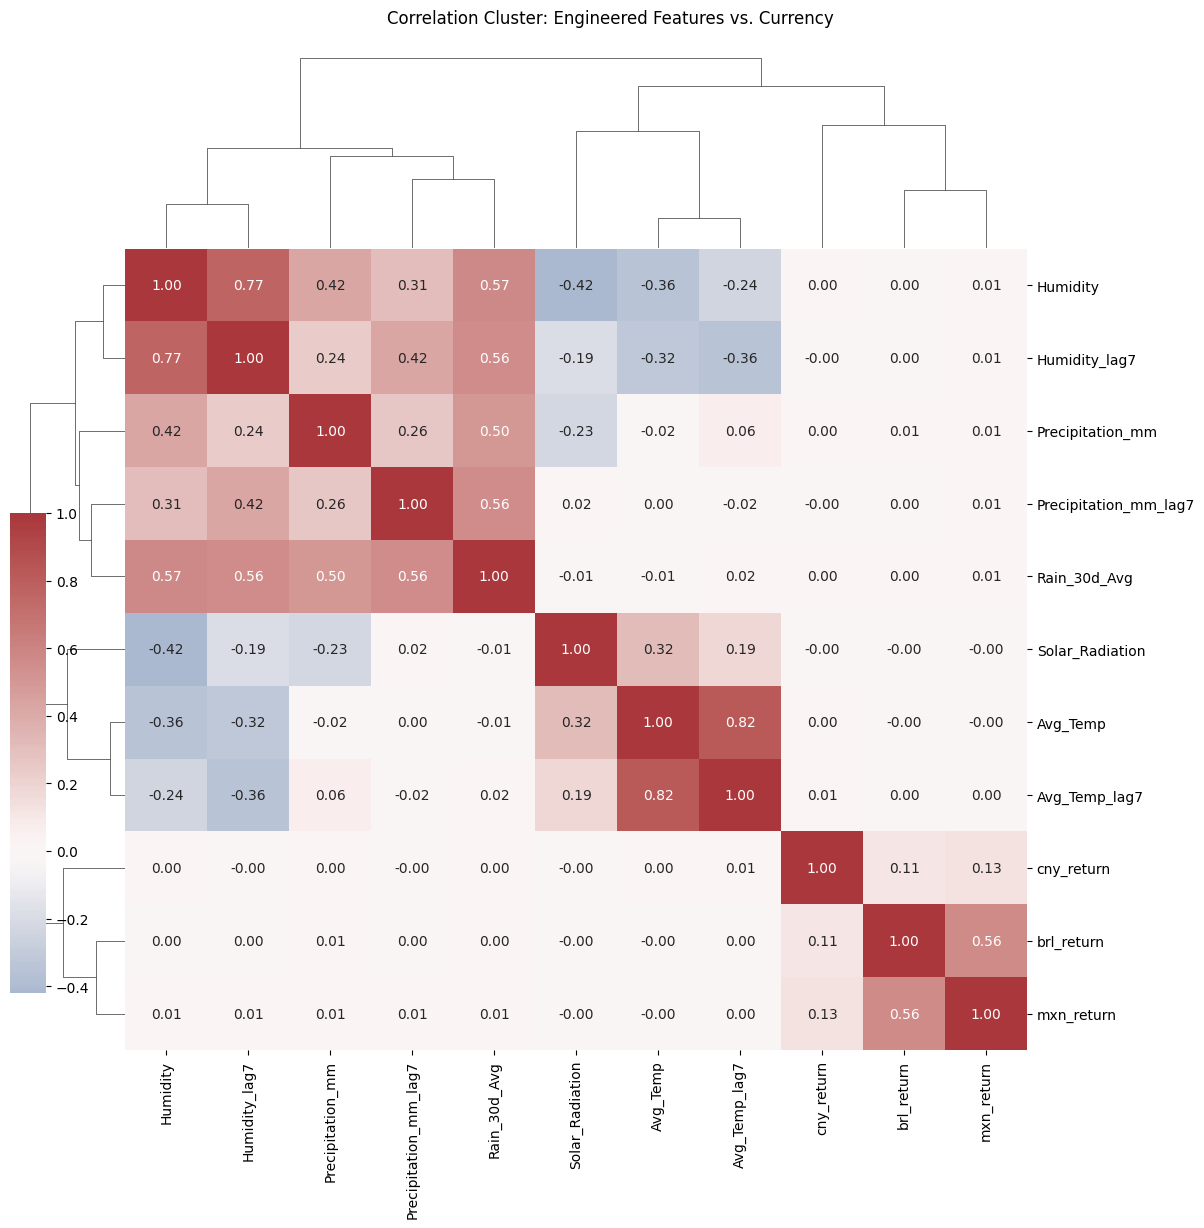

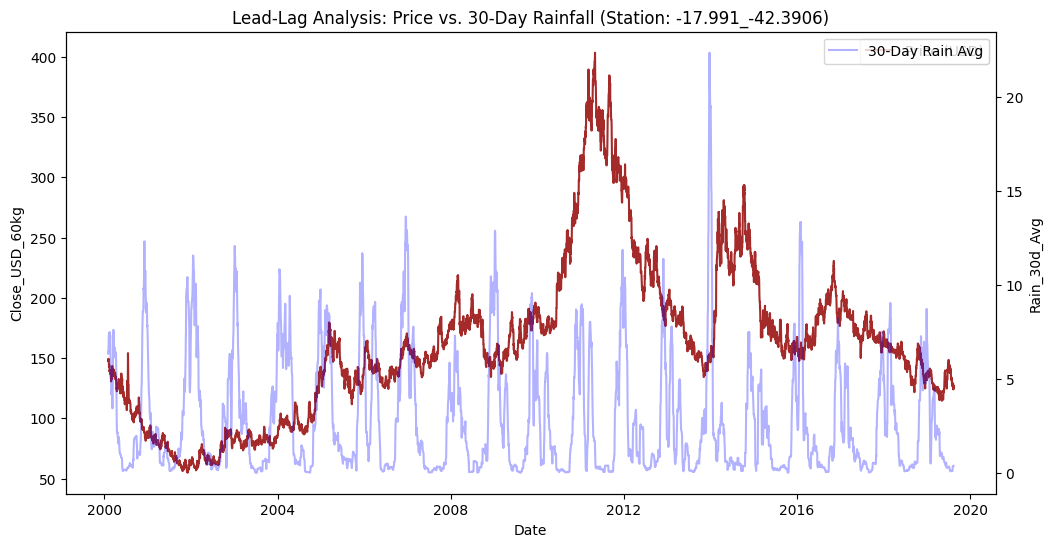

Generating Pair Plot... 


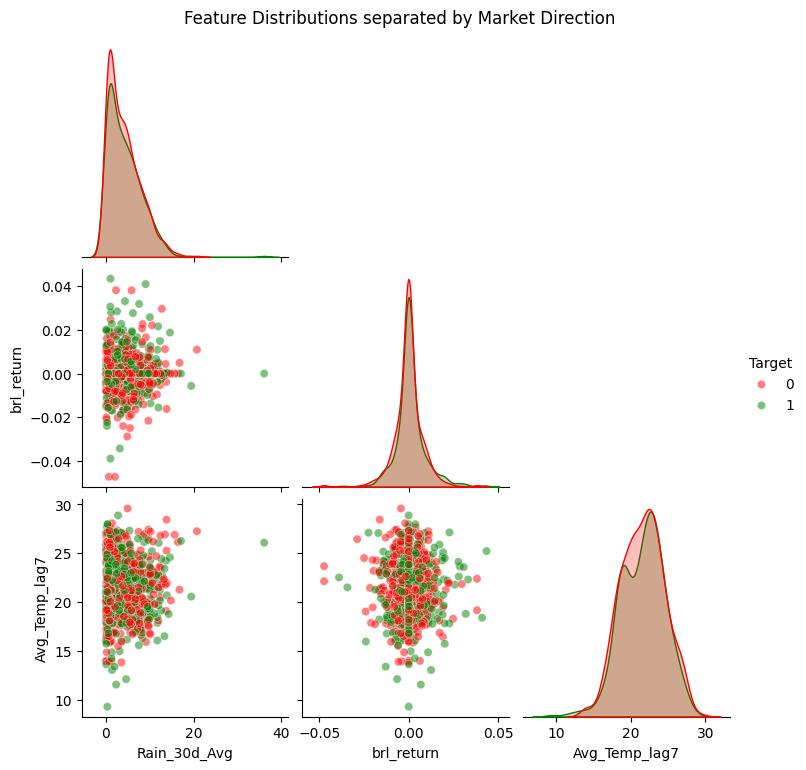

In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

df = pd.read_csv('/content/myDrive/coffee_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Station_ID'] = df['LAT'].astype(str) + "_" + df['LON'].astype(str)

# Sort by Station and Date
df = df.sort_values(by=['Station_ID', 'Date']).reset_index(drop=True)

# Group by location
weather_cols = ['Temp_Min', 'Temp_Max', 'Precipitation_mm', 'Humidity', 'Solar_Radiation']
df[weather_cols] = df.groupby(['LAT', 'LON'])[weather_cols].transform(lambda x: x.fillna(x.median()))

currency_cols = ['brl', 'cny', 'mxn']
df[currency_cols] = df[currency_cols].fillna(df[currency_cols].median())

df['Avg_Temp'] = (df['Temp_Min'] + df['Temp_Max']) / 2

# B. Currency Returns
for col in currency_cols:
    df[f'{col}_return'] = df[col].pct_change().fillna(0)

# Captures delayed impact
lag_cols = ['Precipitation_mm', 'Avg_Temp', 'Humidity']
for col in lag_cols:
    df[f'{col}_lag7'] = df.groupby('Station_ID')[col].shift(7)

# Captures long-term conditions
df['Rain_30d_Avg'] = df.groupby('Station_ID')['Precipitation_mm'].transform(
    lambda x: x.rolling(window=30).mean()
)

df['Future_Price'] = df.groupby(['LAT', 'LON'])['Close_USD_60kg'].shift(-7)
df['Target'] = (df['Future_Price'] > df['Close_USD_60kg']).astype(int)

# Define the Final Feature Set
final_features = [
    'Avg_Temp', 'Precipitation_mm', 'Humidity', 'Solar_Radiation',
    'brl_return', 'cny_return', 'mxn_return',
    'Precipitation_mm_lag7', 'Avg_Temp_lag7', 'Humidity_lag7',
    'Rain_30d_Avg'
]

df_refined = df.dropna(subset=final_features + ['Future_Price']).reset_index(drop=True)

# VIF analysis
print("Variance Inflation Factor")
X_vif = df_refined[final_features]
X_vif_const = add_constant(X_vif)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_const.values, i) for i in range(len(X_vif_const.columns))]
print(vif_data[vif_data['Feature'] != 'const'])

# Clustermap
plt.figure(figsize=(14, 12))
corr_all = df_refined[final_features].corr()
g = sns.clustermap(corr_all, cmap='vlag', annot=True, center=0, fmt='.2f',
                   figsize=(12, 12), dendrogram_ratio=(.1, .2), cbar_pos=(0, .2, .03, .4))
plt.suptitle('Correlation Cluster: Engineered Features vs. Currency', y=1.02)
plt.show()

# Lead-Lag Analysis
plt.figure(figsize=(12, 6))
sample_station = df_refined['Station_ID'].unique()[0]
subset = df_refined[df_refined['Station_ID'] == sample_station]

ax = sns.lineplot(data=subset, x='Date', y='Close_USD_60kg', label='Price (USD)', color='brown')
ax2 = ax.twinx()
sns.lineplot(data=subset, x='Date', y='Rain_30d_Avg', label='30-Day Rain Avg', color='blue', alpha=0.3, ax=ax2)
plt.title(f'Lead-Lag Analysis: Price vs. 30-Day Rainfall (Station: {sample_station})')
plt.show()

# Pair Plot with KDE
print("Generating Pair Plot... ")

key_features = ['Rain_30d_Avg', 'brl_return', 'Avg_Temp_lag7', 'Target']
sample_df = df_refined[key_features].sample(n=min(1000, len(df_refined)), random_state=42)

sns.pairplot(
    sample_df,
    hue='Target',
    diag_kind='kde',
    palette={0: 'red', 1: 'green'},
    plot_kws={'alpha': 0.5},
    corner=True
)
plt.suptitle('Feature Distributions separated by Market Direction', y=1.02)
plt.show()

# Preprocessing decisions

Average Temperature is used to remove the highly correlated min temp and max temp that might confuse the model

Lag features were added after some initial testing because the model could not detect time based trends and instead based the current price off current day features.

Because the goal of the model is classification, the target was changed to binary decisions based off whether the price went up or down the following week.

# Plot intepretations
As for the heatmap for correlation, we can see that humidity and precipitation are correlated, and temperature and radiation are related, which makes sense.

In the pair plot, I chose the most critical features. We can see that the red curve swallows the green curve, meaning that there is no feature that distinguishes the signal from the noise for these specific features. This would lead to hard to learn from data as signal is what is needed for learning.

# VIF steps to take

At first, the min temp and the max temp for each row were highly correlated, demonstrated by a number much above the 5 VIF threshold.

**Corrective Action:** I created an ```Avg_Temp``` feature and dropped the other two. I re-ran the VIF and all the features were under 5, which was below the required threshold.

Training Batch GD...
Training SGD (Sequential)...
Training Mini-Batch GD (Sequential Blocks)...


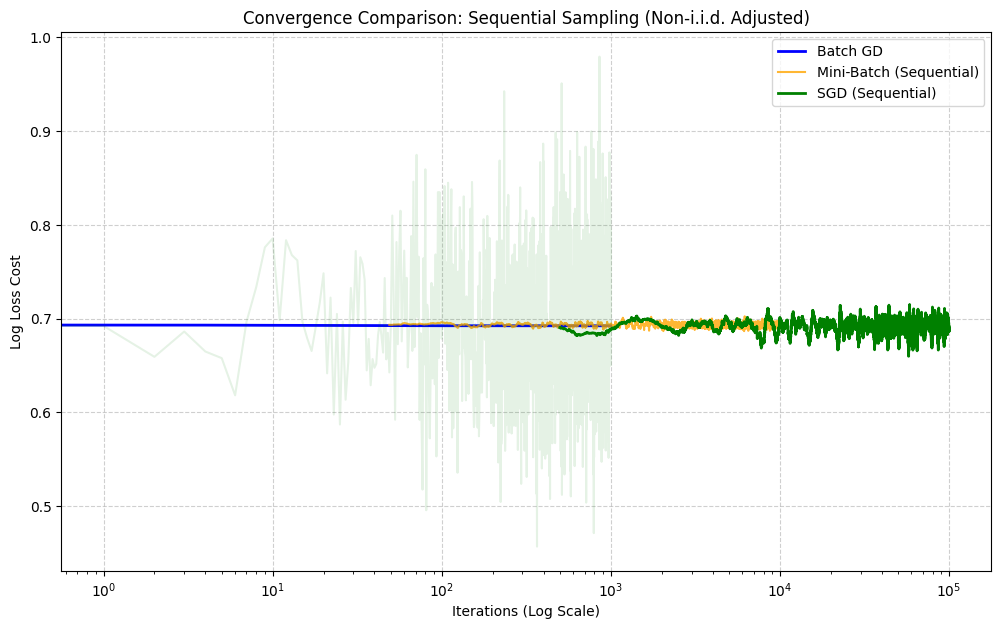

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

class LogisticRegression:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def sigmoid(self, z):
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))

    def cost_function(self, h, y):
        m = len(y)
        epsilon = 1e-15
        return -(1/m) * np.sum(y * np.log(h + epsilon) + (1-y) * np.log(1-h + epsilon))

    def fit(self, X, y, method='batch', batch_size=32, shuffle=True):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.cost_history = []

        current_idx = 0

        for i in range(self.iterations):
            if method == 'batch':
                X_batch, y_batch = X, y

            elif method == 'sgd':
                if shuffle:
                    idx = np.random.randint(0, n_samples)
                    X_batch = X[idx].reshape(1, -1)
                    y_batch = y[idx].reshape(1)
                else:
                    idx = current_idx % n_samples
                    X_batch = X[idx].reshape(1, -1)
                    y_batch = y[idx].reshape(1)
                    current_idx += 1

            elif method == 'mini_batch':
                if shuffle:
                    idx = np.random.choice(n_samples, batch_size, replace=False)
                    X_batch, y_batch = X[idx], y[idx]
                else:
                    start = current_idx % n_samples
                    end = start + batch_size

                    if end <= n_samples:
                        X_batch = X[start:end]
                        y_batch = y[start:end]
                    else:
                        X_batch = np.vstack((X[start:], X[:end % n_samples]))
                        y_batch = np.concatenate((y[start:], y[:end % n_samples]))

                    current_idx += batch_size

            # 1. Forward Pass
            linear_model = np.dot(X_batch, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)

            # 2. Compute Cost
            cost = self.cost_function(y_predicted, y_batch)
            self.cost_history.append(cost)

            # 3. Backward Pass
            m_batch = len(y_batch)
            dw = (1 / m_batch) * np.dot(X_batch.T, (y_predicted - y_batch))
            db = (1 / m_batch) * np.sum(y_predicted - y_batch)

            # 4. Update Parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

refined_features = [
    'Avg_Temp', 'Precipitation_mm', 'Humidity', 'Solar_Radiation',
    'brl_return', 'cny_return', 'mxn_return',
    'Precipitation_mm_lag7', 'Avg_Temp_lag7', 'Humidity_lag7',
    'Rain_30d_Avg'
]
df_model = df_refined.dropna(subset=refined_features + ['Target']).reset_index(drop=True)
X = df_model[refined_features].values
y = df_model['Target'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, shuffle=False
)

print("Training Batch GD...")
model_batch = LogisticRegression(learning_rate=0.1, iterations=1000)
model_batch.fit(X_train, y_train, method='batch')

print("Training SGD (Sequential)...")
model_sgd = LogisticRegression(learning_rate=0.001, iterations=100000)
model_sgd.fit(X_train, y_train, method='sgd', shuffle=False)

print("Training Mini-Batch GD (Sequential Blocks)...")
model_mini = LogisticRegression(learning_rate=0.05, iterations=10000)
model_mini.fit(X_train, y_train, method='mini_batch', batch_size=64, shuffle=False)

def get_rolling_avg(history, window=100):
    return pd.Series(history).rolling(window=window).mean()

plt.figure(figsize=(12, 7))
plt.plot(model_batch.cost_history, label='Batch GD', linewidth=2, color='blue')
plt.plot(get_rolling_avg(model_mini.cost_history, window=50), label='Mini-Batch (Sequential)', alpha=0.8, color='orange', linewidth=1.5)
plt.plot(get_rolling_avg(model_sgd.cost_history, window=500), label='SGD (Sequential)', color='green', linewidth=2)
plt.plot(model_sgd.cost_history[::100], alpha=0.1, color='green', label='_nolegend_')

plt.title('Convergence Comparison: Sequential Sampling (Non-i.i.d. Adjusted)')
plt.xlabel('Iterations (Log Scale)')
plt.ylabel('Log Loss Cost')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xscale('log')
plt.show()

# Preprocessing

Here we do the standard train test split and scaling of the features, which is especially important between differing scales such as radiation and prices.

Next we trained the different models with their respective gradient descent method.

The SGD has a higher iteration count because every iteration processes one point, while batch GD looks through all the points at the same time.

The SGD also has a lower learning rate because of the noise of the method. The lower learning rate means that the weights are updated less each iteration.

When plotting the convergence of the different methods, I used a log scale because of the vastly different iteration counts.

We can see that the SGD is extremely noisy while batch GD is constantly stable. However, all methods have non decreasing log loss costs, meaning that learning is not being done.

# Notes on the convergence

The curve of batch GD is monotonic and smooth. This is because the model calculates the gradient for the entire set of data. The tradeoff of this method is that it is extremely computationally expensive.

The curve of SGD is noisy and erratic. Processing each point one at a time introduces a lot of variance at each iteration. The tradeoff is that the cost function would bounce around the optimal value rather than settling like the batch GD. This could be remedied with other methods where the learning rate is slowly reduced.

Lastly, the curve of mini batch GD is between that of batch GD and SGD, as the amount processed is some at a time, which is between one at a time and all at the same time. This method is balanced and includes the tradeoffs between the other two methods.

https://iamtrask.github.io/2015/07/27/python-network-part2/

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_performance(model, X_test, y_test, name):
    # Generate predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    metrics = {
        "Algorithm": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }

    return metrics, y_pred

results = []
preds_dict = {}

for model, name in zip([model_batch, model_sgd, model_mini],
                       ["Batch GD", "SGD", "Mini-Batch GD"]):
    metric_results, predictions = evaluate_performance(model, X_test, y_test, name)
    results.append(metric_results)
    preds_dict[name] = predictions

results_df = pd.DataFrame(results)
print("--- Final Performance Comparison ---")
print(results_df)

--- Final Performance Comparison ---
       Algorithm  Accuracy  Precision    Recall  F1-Score
0       Batch GD  0.515418   0.490798  0.032436  0.060850
1            SGD  0.516932   0.509081  0.053577  0.096950
2  Mini-Batch GD  0.514914   0.497368  0.213438  0.298695


In [76]:
from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

sgd_vanilla = SGDClassifier(loss='log_loss', penalty=None, learning_rate='constant', eta0=0.01, random_state=42, class_weight='balanced')
sgd_vanilla.fit(X_train, y_train)

# Momentum
momentum_model = MLPClassifier(hidden_layer_sizes=(), solver='sgd', momentum=0.9,
                               learning_rate_init=0.01, max_iter=1000, random_state=42)
momentum_model.fit(X_train, y_train)

# Adam
adam_model = MLPClassifier(hidden_layer_sizes=(), solver='adam', learning_rate_init=0.001,
                           max_iter=1000, random_state=42)
adam_model.fit(X_train, y_train)

# RMSprop
rmsprop_model = SGDClassifier(loss='log_loss', learning_rate='invscaling', eta0=0.01,
                              power_t=0.5, random_state=42)
rmsprop_model.fit(X_train, y_train)

# Evaluation & Comparison

def get_performance(model, name):
    y_pred = model.predict(X_test)
    return {
        "Algorithm": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }

evaluations = [
    get_performance(sgd_vanilla, "Vanilla SGD"),
    get_performance(momentum_model, "Momentum (SGD)"),
    get_performance(adam_model, "Adam"),
    get_performance(rmsprop_model, "RMSprop")
]

print(pd.DataFrame(evaluations))

        Algorithm  Accuracy  Precision    Recall  F1-Score
0     Vanilla SGD  0.508186   0.482994  0.229482  0.311136
1  Momentum (SGD)  0.512503   0.478441  0.080336  0.137572
2            Adam  0.516315   0.506433  0.025080  0.047792
3         RMSprop  0.515362   0.486976  0.024906  0.047388


# Comparison

The advanced techniques using the libraries have comparable accuracy to that of SGD in task 3. However, there is no statistically significant change between these algorithms, indicating difficulty of learning from the data no matter the method.

# Advanced metric analysis

**Interpretation of Results**: *The "Lazy Learner" Phenomenon*. The results show an accuracy of 52% but a Recall of nearly 0% for the advanced optimizers (Adam/RMSprop).

**Recall Collapse**: Because most of the data is either flat or dropping in price (0), the Adam optimizer likely chose all 0 because it wants to have the lowest accuracy. Without adequate data, there is no better option than an "probablistic" coin flip.

**Why SGD had higher Recall**: Vanilla SGD is noisier. This noise prevented it from settling perfectly into the global minimum, causing it to accidentally predict (1) more often, resulting in a higher (but likely coincidental) Recall.

In [78]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform
import pandas as pd


# Vanilla SGD: Tuning Initial Learning Rate (eta0) & Regularization (alpha)
param_dist_sgd = {
    'eta0': loguniform(1e-4, 1e-1),
    'alpha': loguniform(1e-5, 1e-1)
}

# Momentum: Tuning Momentum factor, Learning Rate, & Alpha
param_dist_momentum = {
    'learning_rate_init': loguniform(1e-4, 1e-1),
    'momentum': uniform(0.5, 0.49),
    'alpha': loguniform(1e-5, 1e-1)
}

# Adam: Tuning Learning Rate & Alpha
param_dist_adam = {
    'learning_rate_init': loguniform(1e-4, 1e-1),
    'alpha': loguniform(1e-5, 1e-1)
}

# RMSprop: Tuning Learning Rate, Decay (power_t), & Alpha
param_dist_rmsprop = {
    'eta0': loguniform(1e-4, 1e-1),
    'power_t': uniform(0.1, 0.8),
    'alpha': loguniform(1e-5, 1e-1)
}

# Perform Randomized Search

print("Tuning Vanilla SGD...")
tune_sgd = RandomizedSearchCV(
    sgd_vanilla, param_dist_sgd, n_iter=20, cv=3, scoring='f1', random_state=42
)
tune_sgd.fit(X_train, y_train)

print("Tuning Momentum...")
tune_momentum = RandomizedSearchCV(
    momentum_model, param_dist_momentum, n_iter=20, cv=3, scoring='f1', random_state=42
)
tune_momentum.fit(X_train, y_train)

print("Tuning Adam...")
tune_adam = RandomizedSearchCV(
    adam_model, param_dist_adam, n_iter=20, cv=3, scoring='f1', random_state=42
)
tune_adam.fit(X_train, y_train)

print("Tuning RMSprop...")
tune_rmsprop = RandomizedSearchCV(
    rmsprop_model, param_dist_rmsprop, n_iter=20, cv=3, scoring='f1', random_state=42
)
tune_rmsprop.fit(X_train, y_train)

# Evaluate
tuned_evaluations = [
    get_performance(tune_sgd.best_estimator_, "Vanilla SGD (Tuned)"),
    get_performance(tune_momentum.best_estimator_, "Momentum (Tuned)"),
    get_performance(tune_adam.best_estimator_, "Adam (Tuned)"),
    get_performance(tune_rmsprop.best_estimator_, "RMSprop (Tuned)")
]

df_tuned = pd.DataFrame(tuned_evaluations)
print("\nOptimized Performance Results ")
print(df_tuned)

print("\nBest Parameters Found")
print(f"Vanilla SGD: {tune_sgd.best_params_}")
print(f"Momentum:    {tune_momentum.best_params_}")
print(f"Adam:        {tune_adam.best_params_}")
print(f"RMSprop:     {tune_rmsprop.best_params_}")

Tuning Vanilla SGD...
Tuning Momentum...
Tuning Adam...
Tuning RMSprop...

Optimized Performance Results 
             Algorithm  Accuracy  Precision    Recall  F1-Score
0  Vanilla SGD (Tuned)  0.507653   0.487688  0.341848  0.401948
1     Momentum (Tuned)  0.487974   0.469531  0.446279  0.457610
2         Adam (Tuned)  0.509503   0.490007  0.329453  0.394001
3      RMSprop (Tuned)  0.524221   0.511791  0.368317  0.428360

Best Parameters Found
Vanilla SGD: {'alpha': np.float64(0.07286653737491042), 'eta0': np.float64(0.026619018884890575)}
Momentum:    {'alpha': np.float64(0.012604664585649461), 'learning_rate_init': np.float64(0.06584106160121614), 'momentum': np.float64(0.938465401709548)}
Adam:        {'alpha': np.float64(1.2087541473056957e-05), 'learning_rate_init': np.float64(0.0812324508558869)}
RMSprop:     {'alpha': np.float64(0.006796578090758156), 'eta0': np.float64(0.00011527987128232407), 'power_t': np.float64(0.8759278817295955)}


# Tuning analysis

After tuning the hyperparameters using randomized search, the F1 scores and the recall metrics greatly went up, at the sacrifice for some accuracy (which is good, we want some correct positives in there).

It seems like momentum has the best recall metric, which makes sense. Momentum is good for noisy data as the momentum vector pulls the weights in the generally correct direction, "plowing" through the noise that it meets.

# Trade off analysis

Although centered around SGD, all the algorithms have different ways to treat learning rate and momentum vectors, leading to different time and space complexities and use cases.

## Complexity
**Vanilla SGD:**

*   Space complexity: O(n)
*   Time Complexity: Low

Since this algorithm requires only the current weights, it's space complexity is O(n). Time complexity is low because it performs a simple update each iteration $$w = w - η\nabla$$


**Momentum:**

*   Space complexity: 2 * O(n)
*   Time Complexity: Moderate

This algorithm requires storing both the weight vector and the momentum vector, both size n. It adds a calculation to blend the past momentum with the current gradient

**RMSprop:**

*   Space complexity: 2 * O(n)
*   Time Complexity: Moderate

Requires storing the weights and a squared gradient history. There is an additional calculation of a square root and division operation per iteration.

**Adam:**

*   Space complexity: 3 * O(n)
*   Time Complexity: High

There are three n sized vectors to be stored: weights, first moment, second moment. The extra time complexity comes from calculating first moment and second moment estimates per iteration.

Something to note is how space complexity correlates with time complexity for these models because the amount of vectors need to be updated each iteration, leading to a linearly correlated time complexity and space complexity.


## Large scale learning

**Computational Complexity**: While Batch GD offers the most stable convergence, it is computationally expensive ($O(N)$ per step) and unsuitable for streaming data. Adam adds memory overhead (storing moments for every parameter) but converges significantly faster in terms of epochs.

**Suitability for Large Scale**: Mini-Batch SGD represents the optimal trade-off. It allows for vectorization while maintaining enough noise to escape local minima.

**Final Verdict**: For financial time-series where the signal-to-noise ratio is low, Feature Engineering proved more critical than the choice of optimizer. The "Recall Collapse" indicates that without stronger features, even advanced optimizers like Adam will default to the majority class.

https://arxiv.org/pdf/1412.6980




# Explaination of the overall results

You can notice the poor performance of these models, where they barely  broke above a coin flip in accuracy and never breaking above 50 percent for the other metrics. There could be a few reasons behind this:

*   **Model insuffciency**: Logistic regression is just not a strong enough algorithm to capture the complexity behind these moving parts. The strength is basically linear, which has high bias when it comes to evaluating complex data.

*   **Learning is not possible**: There are not enough features in this data to be able to learn effectively and pass a threshold for out of sample error. This happens often with financial data, where we would need more macro level information to be able to beat the market prediction, especially with quant firms having access to this data faster - the price will jump  before you can react to it.


